# **Face Swap**

In this project, we will be using OpenCV and D-Lip to extract faces of human beings from a given image. We will use a pre-trained model to extract landmarks from the faces.

In [1]:
!pip install dlib
import cv2
import numpy as np
import dlib
import requests
from PIL import Image

We will start by importing some required libraries.

In [2]:
!wget 'https://github.com/tzutalin/dlib-android/raw/master/data/shape_predictor_68_face_landmarks.dat'

--2026-03-30 05:06:35--  https://github.com/tzutalin/dlib-android/raw/master/data/shape_predictor_68_face_landmarks.dat
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/tzutalin/dlib-android/master/data/shape_predictor_68_face_landmarks.dat [following]
--2026-03-30 05:06:35--  https://raw.githubusercontent.com/tzutalin/dlib-android/master/data/shape_predictor_68_face_landmarks.dat
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 99693937 (95M) [application/octet-stream]
Saving to: ‘shape_predictor_68_face_landmarks.dat’

shape_predictor_68_ 100%[===================>]  95.08M   108MB/s    in 0.9s  

Now we will download the pre-trained model shape predictor from GitHub into our Google Colab.

In [3]:
def extract_index_nparray(nparray):
  index = None
  for num in nparray[0]:
    index = num
    break
  return index

Now we will create a function to extract the index from the numpy array.

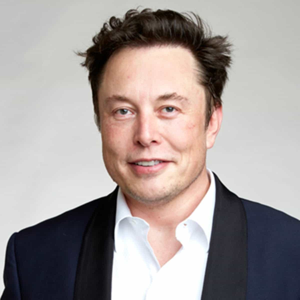

In [4]:
image1 = Image.open(requests.get('https://futureoflife.org/wp-content/uploads/2020/08/elon_musk_royal_society.jpg', stream=True).raw)
image1 = image1.resize((300,300))
image1

Next we will load our source image from the internet using url and resize it.

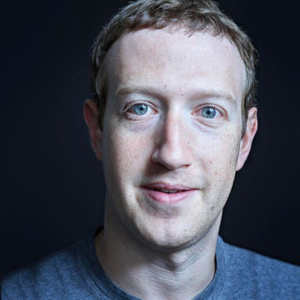

In [5]:
image2 = Image.open(requests.get('https://imageio.forbes.com/specials-images/imageserve/5c76b7d331358e35dd2773a9/0x0.jpg?format=jpg&crop=4401,4401,x0,y0,safe&height=416&width=416&fit=bounds', stream=True).raw)
image2 = image2.resize((300,300))
image2

Here we will load our destination image form the interner using url and resize it.

In [6]:
img = np.array(image1)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
mask = np.zeros_like(img_gray)

img2 = np.array(image2)
img2_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

Now  we will convert our images into numpy array and use cv2 to convert it into grayscale. We will also create empty image or mask similiar to our source image with zeros.

In [7]:
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")

height, width, channels = img2.shape
img2_new_face = np.zeros((height, width, channels), np.uint8)

Here we will first load Face detector and Face landmarks predictor using dlib and then we will find the height, width, channels which are required for creating empty image with zeros.

In [8]:
# Face 1
faces = detector(img_gray)
for face in faces:
    landmarks = predictor(img_gray, face)
    landmarks_points = []
    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        landmarks_points.append((x, y))

points = np.array(landmarks_points, np.int32)
convexhull = cv2.convexHull(points)
cv2.fillConvexPoly(mask, convexhull, 255)

face_image_1 = cv2.bitwise_and(img, img, mask=mask)

# Delaunay triangulation
rect = cv2.boundingRect(convexhull)
subdiv = cv2.Subdiv2D(rect)
subdiv.insert(landmarks_points)
triangles = subdiv.getTriangleList()
triangles = np.array(triangles, dtype=np.int32)
indexes_triangles = []
for t in triangles:
    pt1 = (t[0], t[1])
    pt2 = (t[2], t[3])
    pt3 = (t[4], t[5])

    index_pt1 = np.where((points == pt1).all(axis=1))
    index_pt1 = extract_index_nparray(index_pt1)

    index_pt2 = np.where((points == pt2).all(axis=1))
    index_pt2 = extract_index_nparray(index_pt2)

    index_pt3 = np.where((points == pt3).all(axis=1))
    index_pt3 = extract_index_nparray(index_pt3)

    if index_pt1 is not None and index_pt2 is not None and index_pt3 is not None:
        triangle = [index_pt1, index_pt2, index_pt3]
        indexes_triangles.append(triangle)

First we need to pass image to detector then that object will used to extract landmarks using predictor. Then storing extracted landmarks points x and y into landmarks points list. We're going then to segment the face into triangles. This step is the core of our face swapping, as later we will simply exchange each triangle with the correspondent triangle of the destination image. The triangulation of the destination image needs to have the same patterns of the triangulation of the source image. That means that the connection of the points has to be the same. So after we do the triangulation of the source image, from that triangulation we take the indexes of the landmark points so that we can replicate the same triangulation on the destination image. Once we have the triangles indexes we loop through them and we triangulate the destination face.

In [9]:
# Face 2
faces2 = detector(img2_gray)
for face in faces2:
    landmarks = predictor(img2_gray, face)
    landmarks_points2 = []
    for n in range(0, 68):
        x = landmarks.part(n).x
        y = landmarks.part(n).y
        landmarks_points2.append((x, y))

points2 = np.array(landmarks_points2, np.int32)
convexhull2 = cv2.convexHull(points2)

Now we will apply a similar function as done for the source images  to extract landmarks.

In [10]:
lines_space_mask = np.zeros_like(img_gray)
lines_space_new_face = np.zeros_like(img2)

Here we will create empty images with zeros which will be required for further processing.

In [11]:
# Triangulation of both faces
for triangle_index in indexes_triangles:

    # Triangulation of the first face
    tr1_pt1 = landmarks_points[triangle_index[0]]
    tr1_pt2 = landmarks_points[triangle_index[1]]
    tr1_pt3 = landmarks_points[triangle_index[2]]
    triangle1 = np.array([tr1_pt1, tr1_pt2, tr1_pt3], np.int32)

    rect1 = cv2.boundingRect(triangle1)
    (x, y, w, h) = rect1
    cropped_triangle = img[y:y + h, x:x + w]
    cropped_tr1_mask = np.zeros((h, w), np.uint8)

    points = np.array([
        [tr1_pt1[0] - x, tr1_pt1[1] - y],
        [tr1_pt2[0] - x, tr1_pt2[1] - y],
        [tr1_pt3[0] - x, tr1_pt3[1] - y]
    ], np.int32)

    cv2.fillConvexPoly(cropped_tr1_mask, points, 255)

    # Lines space
    cv2.line(lines_space_mask, tr1_pt1, tr1_pt2, 255)
    cv2.line(lines_space_mask, tr1_pt2, tr1_pt3, 255)
    cv2.line(lines_space_mask, tr1_pt1, tr1_pt3, 255)
    lines_space = cv2.bitwise_and(img, img, mask=lines_space_mask)

    # Triangulation of second face
    tr2_pt1 = landmarks_points2[triangle_index[0]]
    tr2_pt2 = landmarks_points2[triangle_index[1]]
    tr2_pt3 = landmarks_points2[triangle_index[2]]
    triangle2 = np.array([tr2_pt1, tr2_pt2, tr2_pt3], np.int32)

    rect2 = cv2.boundingRect(triangle2)
    (x, y, w, h) = rect2

    cropped_tr2_mask = np.zeros((h, w), np.uint8)

    points2 = np.array([
        [tr2_pt1[0] - x, tr2_pt1[1] - y],
        [tr2_pt2[0] - x, tr2_pt2[1] - y],
        [tr2_pt3[0] - x, tr2_pt3[1] - y]
    ], np.int32)

    cv2.fillConvexPoly(cropped_tr2_mask, points2, 255)

    # Warp triangles
    points = np.float32(points)
    points2 = np.float32(points2)
    M = cv2.getAffineTransform(points, points2)
    warped_triangle = cv2.warpAffine(cropped_triangle, M, (w, h))
    warped_triangle = cv2.bitwise_and(
        warped_triangle, warped_triangle, mask=cropped_tr2_mask
    )

    # Reconstructing destination face
    img2_new_face_rect_area = img2_new_face[y:y + h, x:x + w]
    img2_new_face_rect_area_gray = cv2.cvtColor(
        img2_new_face_rect_area, cv2.COLOR_BGR2GRAY
    )

    _, mask_triangles_designed = cv2.threshold(
        img2_new_face_rect_area_gray, 1, 255, cv2.THRESH_BINARY_INV
    )

    warped_triangle = cv2.bitwise_and(
        warped_triangle, warped_triangle, mask=mask_triangles_designed
    )

    img2_new_face_rect_area = cv2.add(img2_new_face_rect_area, warped_triangle)
    img2_new_face[y:y + h, x:x + w] = img2_new_face_rect_area

Here we are performing same operations as above for the destination image. After we have the triangulation of both faces we take the triangles of the source face and we extract them. We also need to take the coordinates of the triangles of the destination face, so that we can warp the triangles of the source face to have same size and perspective of the matching triangle on the destination face.

In [12]:
# Face swapped (putting 1st face into 2nd face)
img2_face_mask = np.zeros_like(img2_gray)
img2_head_mask = cv2.fillConvexPoly(img2_face_mask, convexhull2, 255)
img2_face_mask = cv2.bitwise_not(img2_head_mask)

Once we have cut and wrapped all the triangles, we need to link them together. We simply rebuild the face using the triangulation  pattern, with the only difference that this time ,we put the wrapped triangle.

In [13]:
img2_head_noface = cv2.bitwise_and(img2, img2, mask=img2_face_mask)
result = cv2.add(img2_head_noface, img2_new_face)

The face is now ready to be replaced. We cut out the face of the destination image to make space for the new face. We take the new face and the destination image without face, and we link them together.

In [14]:
(x, y, w, h) = cv2.boundingRect(convexhull2)
center_face2 = (int((x + x + w) / 2), int((y + y + h) / 2))
seamlessClone = cv2.seamlessClone(result, img2, img2_head_mask, center_face2, cv2.NORMAL_CLONE)

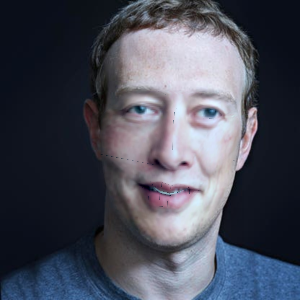

In [16]:
Image.fromarray(seamlessClone)

Finally we will visualize output numpy image by convert it into Image object of Pillow.

# **Conclusion**

We started with downloading the pre-trained model for Face landmark ANDO DOWNLOAD THE IMAGES FROM THE INTERNET ON WHICH WE WILL WORK. NEXT WE USED THE cv2 AND dLIB FIOR PREPROCESSING THE IMAGES AND USED THE DIFFRENT FUNCTIONALITIES TO MAKE REACH THE END OF THE SWAPPING OF THE FACE OF DESTINATION IMAGE.

# **Scope**

this project can be used for learning and understanding diffrent concepts of computer vision. This project can be used to build Augmented Reality applications like snapchat,etc.